# Task 02: Exploratory Data Analysis (EDA) 📊
### Comprehensive Statistical & Visual Analysis of Student Performance

**Task Objective:**
- Perform Exploratory Data Analysis (EDA) to understand patterns, distributions, and relationships in the data.
- Analyze statistical summaries (central tendency, dispersion, skewness).
- Generate visualizations: **Bar charts, Histograms with KDE, Correlation Heatmaps, Box plots, and Scatter plots**.
- Extract and summarize meaningful insights to inform future machine learning model building.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Visualization aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Data Ingestion & Structural Inspection

In [2]:
# Load the dataset (handles running from folder or root)
data_path = 'student_performance.csv' if os.path.exists('student_performance.csv') else 'Task-2 (EDA)/student_performance.csv'
df = pd.read_csv(data_path)

print(f'Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns')
df.head(5)

Dataset Shape: 917 rows, 12 columns


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study_Hours,Attendance_Pct,Online_Classes_Taken
0,8998,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,5638,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,8783,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,9867,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,87549,Emma,Female,88.0,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [3]:
# Column info and non-null confirmation
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 917 entries, 0 to 916
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  917 non-null    int64  
 1   Name                       917 non-null    str    
 2   Gender                     917 non-null    str    
 3   AttendanceRate             917 non-null    float64
 4   StudyHoursPerWeek          917 non-null    float64
 5   PreviousGrade              917 non-null    float64
 6   ExtracurricularActivities  917 non-null    float64
 7   ParentalSupport            917 non-null    str    
 8   FinalGrade                 917 non-null    float64
 9   Study_Hours                917 non-null    float64
 10  Attendance_Pct             917 non-null    float64
 11  Online_Classes_Taken       917 non-null    bool   
dtypes: bool(1), float64(7), int64(1), str(3)
memory usage: 100.0 KB


In [4]:
# Check summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
StudentID,917.0,5595.403490,3755.639117,1019.0,3257.0,5489.0,7797.0,87549.0
AttendanceRate,917.0,85.599782,7.186696,70.0,82.0,88.0,91.0,95.0
StudyHoursPerWeek,917.0,17.521265,6.099506,8.0,12.0,17.0,22.0,30.0
PreviousGrade,917.0,77.738277,9.840274,60.0,70.0,78.0,86.0,90.0
ExtracurricularActivities,917.0,1.546347,1.024418,0.0,1.0,2.0,2.0,3.0
FinalGrade,917.0,80.286805,9.255564,62.0,72.0,80.0,88.0,92.0
Study_Hours,917.0,2.386041,1.618905,-5.0,1.2,2.5,3.7,5.0
Attendance_Pct,917.0,77.431843,19.299325,50.0,64.0,76.0,89.0,200.0


## 2. Statistical Profiling: Central Tendency, Spread & Skewness

In [5]:
# Compute skewness and kurtosis for numerical features
num_cols = ['FinalGrade', 'PreviousGrade', 'AttendanceRate', 'StudyHoursPerWeek', 'Study_Hours', 'Attendance_Pct']

stat_metrics = []
for col in num_cols:
    stat_metrics.append({
        'Feature': col,
        'Mean': round(df[col].mean(), 2),
        'Median': round(df[col].median(), 2),
        'Std Dev': round(df[col].std(), 2),
        'Min': round(df[col].min(), 2),
        'Max': round(df[col].max(), 2),
        'Skewness': round(df[col].skew(), 2),
        'Kurtosis': round(df[col].kurt(), 2)
    })

stat_df = pd.DataFrame(stat_metrics)
print('Detailed Statistical Metrics:')
stat_df

Detailed Statistical Metrics:


,Feature,Mean,Median,Std Dev,Min,Max,Skewness,Kurtosis
0,FinalGrade,80.29,80.0,9.26,62.0,92.0,-0.57,-0.82
1,PreviousGrade,77.74,78.0,9.84,60.0,90.0,-0.52,-1.04
2,AttendanceRate,85.60,88.0,7.19,70.0,95.0,-0.87,-0.06
3,StudyHoursPerWeek,17.52,17.0,6.10,8.0,30.0,0.29,-0.52
4,Study_Hours,2.39,2.5,1.62,-5.0,5.0,-0.94,2.85
5,Attendance_Pct,77.43,76.0,19.30,50.0,200.0,2.66,15.47


## 3. Univariate Analysis: Distributions of Numerical & Categorical Features

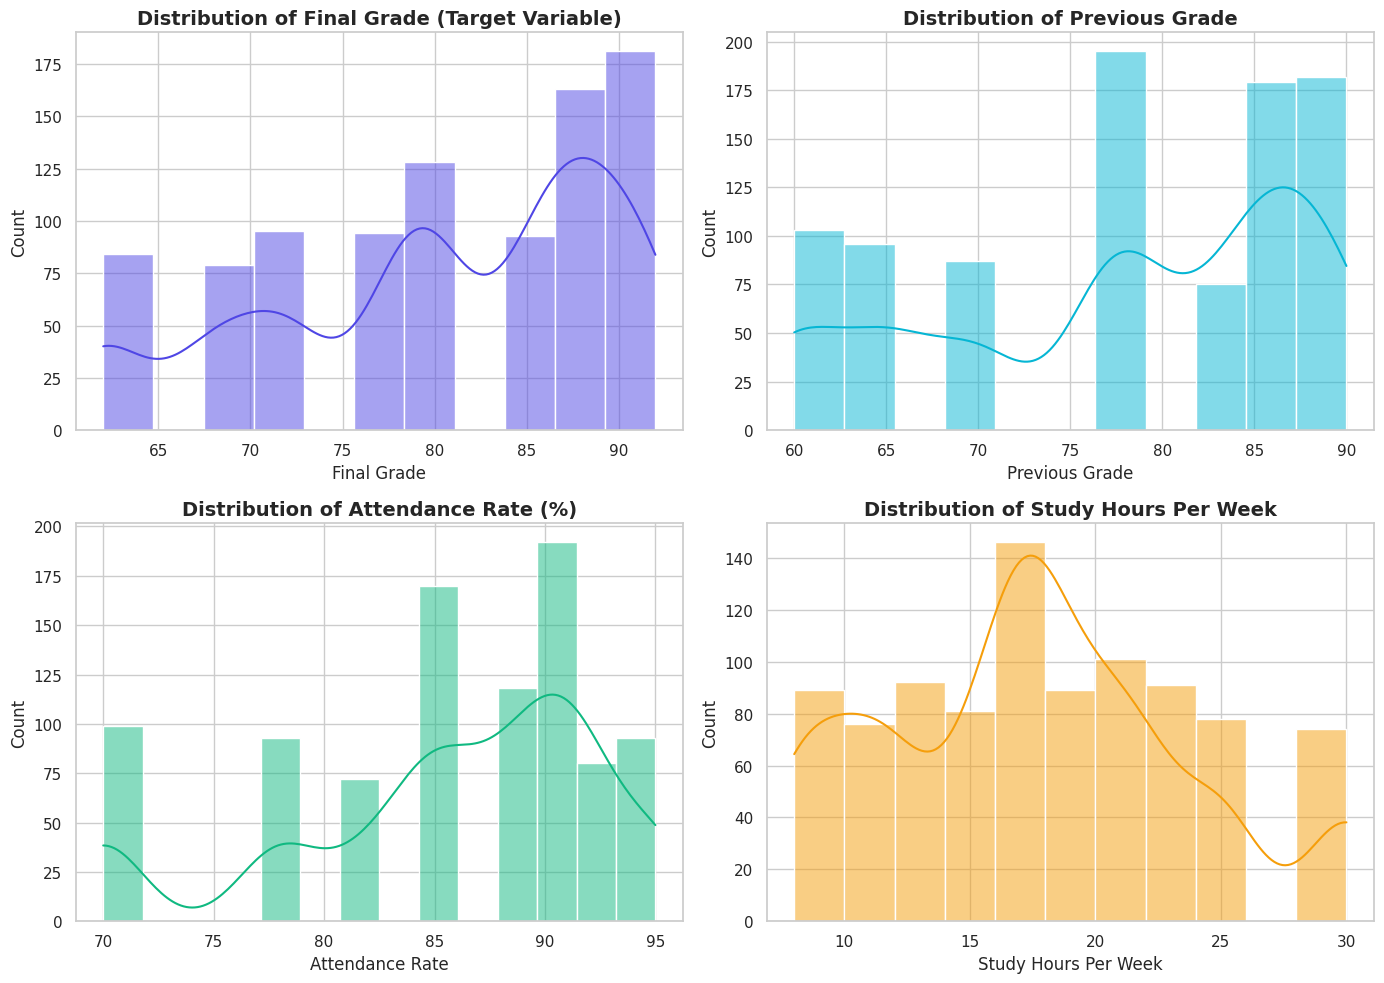

In [6]:
# 3.1 Histograms with KDE for Key Numerical Variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['FinalGrade'], kde=True, color='#4F46E5', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Final Grade (Target Variable)', fontweight='bold')
axes[0, 0].set_xlabel('Final Grade')

sns.histplot(df['PreviousGrade'], kde=True, color='#06B6D4', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Previous Grade', fontweight='bold')
axes[0, 1].set_xlabel('Previous Grade')

sns.histplot(df['AttendanceRate'], kde=True, color='#10B981', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Attendance Rate (%)', fontweight='bold')
axes[1, 0].set_xlabel('Attendance Rate')

sns.histplot(df['StudyHoursPerWeek'], kde=True, color='#F59E0B', ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Study Hours Per Week', fontweight='bold')
axes[1, 1].set_xlabel('Study Hours Per Week')

plt.tight_layout()
plt.show()

C:\Users\subha\AppData\Local\Temp\ipykernel_21472\275506914.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette=['#3B82F6', '#EC4899'], ax=axes[0])
C:\Users\subha\AppData\Local\Temp\ipykernel_21472\275506914.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='ParentalSupport', order=order_support, palette='Purples_r', ax=axes[1])
C:\Users\subha\AppData\Local\Temp\ipykernel_21472\275506914.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Online_Classes_Taken', palette=['#6B7280',

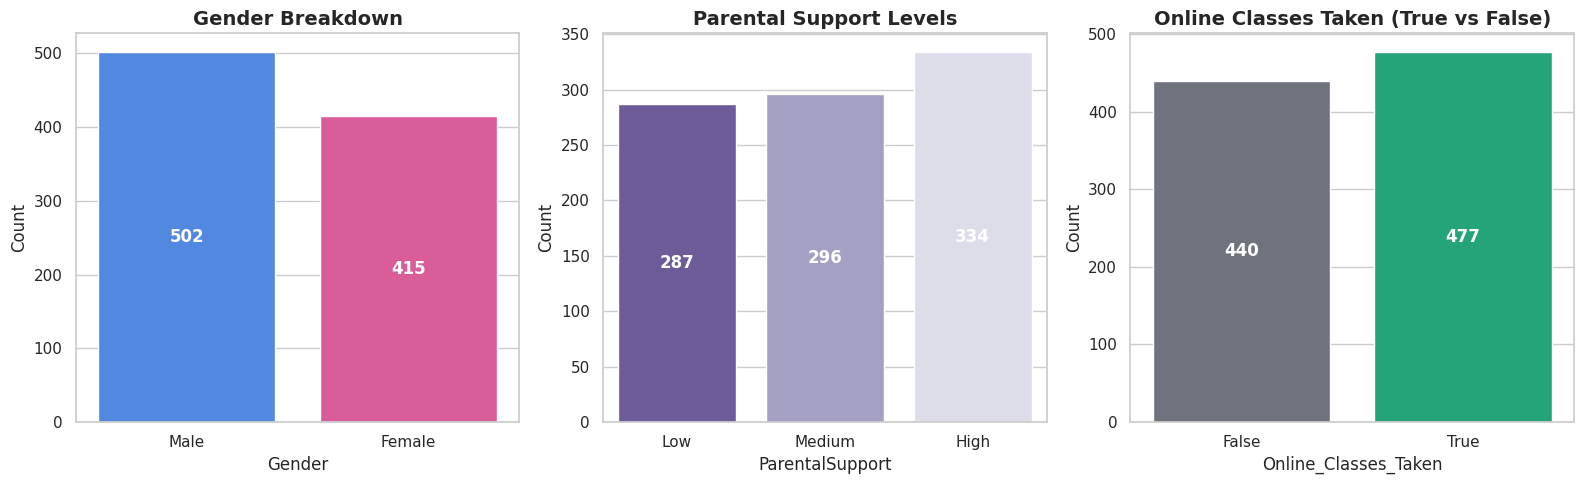

In [7]:
# 3.2 Categorical Feature Distributions (Bar Charts)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gender breakdown
sns.countplot(data=df, x='Gender', palette=['#3B82F6', '#EC4899'], ax=axes[0])
axes[0].set_title('Gender Breakdown', fontweight='bold')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold')

# Parental Support breakdown
order_support = ['Low', 'Medium', 'High']
sns.countplot(data=df, x='ParentalSupport', order=order_support, palette='Purples_r', ax=axes[1])
axes[1].set_title('Parental Support Levels', fontweight='bold')
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold')

# Online Classes Taken
sns.countplot(data=df, x='Online_Classes_Taken', palette=['#6B7280', '#10B981'], ax=axes[2])
axes[2].set_title('Online Classes Taken (True vs False)', fontweight='bold')
axes[2].set_ylabel('Count')
for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Bivariate Analysis: Relationships with Final Grade

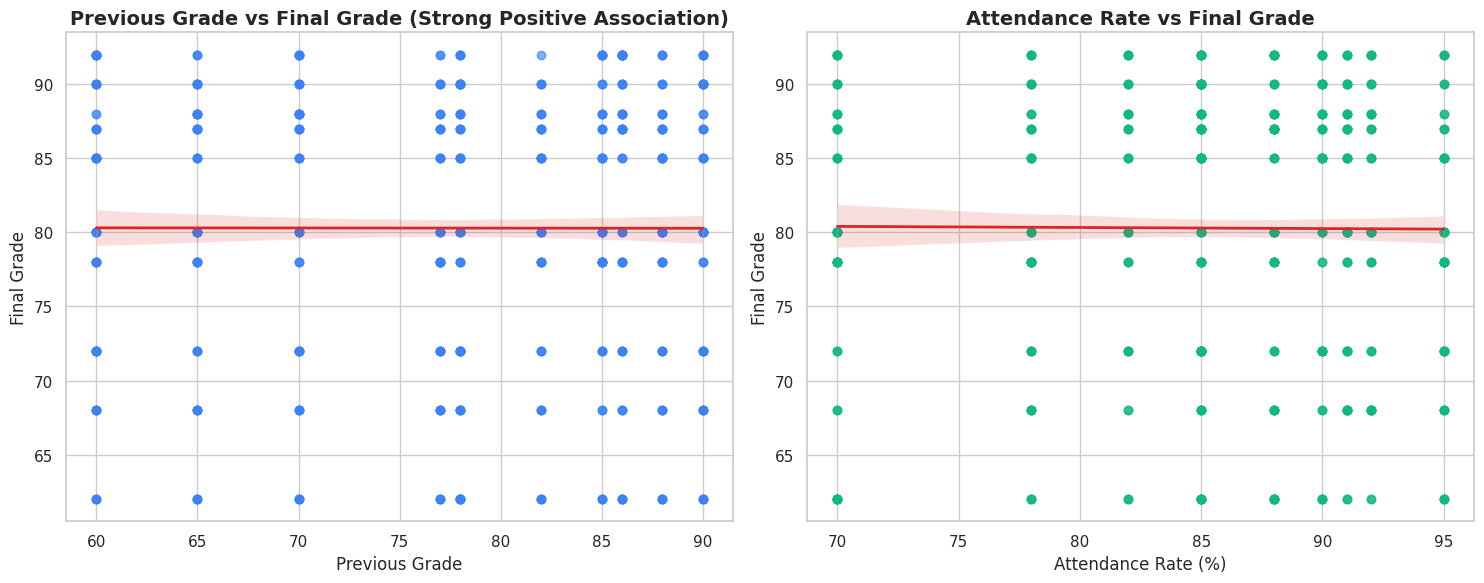

In [8]:
# 4.1 Previous Grade vs Final Grade & Attendance vs Final Grade
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot with regression line: Previous Grade vs Final Grade
sns.regplot(data=df, x='PreviousGrade', y='FinalGrade', ax=axes[0],
            scatter_kws={'alpha': 0.4, 'color': '#3B82F6'}, line_kws={'color': '#DC2626', 'linewidth': 2})
axes[0].set_title('Previous Grade vs Final Grade (Strong Positive Association)', fontweight='bold')
axes[0].set_xlabel('Previous Grade')
axes[0].set_ylabel('Final Grade')

# Scatter plot with regression line: Attendance Rate vs Final Grade
sns.regplot(data=df, x='AttendanceRate', y='FinalGrade', ax=axes[1],
            scatter_kws={'alpha': 0.4, 'color': '#10B981'}, line_kws={'color': '#DC2626', 'linewidth': 2})
axes[1].set_title('Attendance Rate vs Final Grade', fontweight='bold')
axes[1].set_xlabel('Attendance Rate (%)')
axes[1].set_ylabel('Final Grade')

plt.tight_layout()
plt.show()

C:\Users\subha\AppData\Local\Temp\ipykernel_21472\1353471374.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ParentalSupport', y='FinalGrade', order=['Low', 'Medium', 'High'],
C:\Users\subha\AppData\Local\Temp\ipykernel_21472\1353471374.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='ParentalSupport', y='FinalGrade', order=['Low', 'Medium', 'High'],


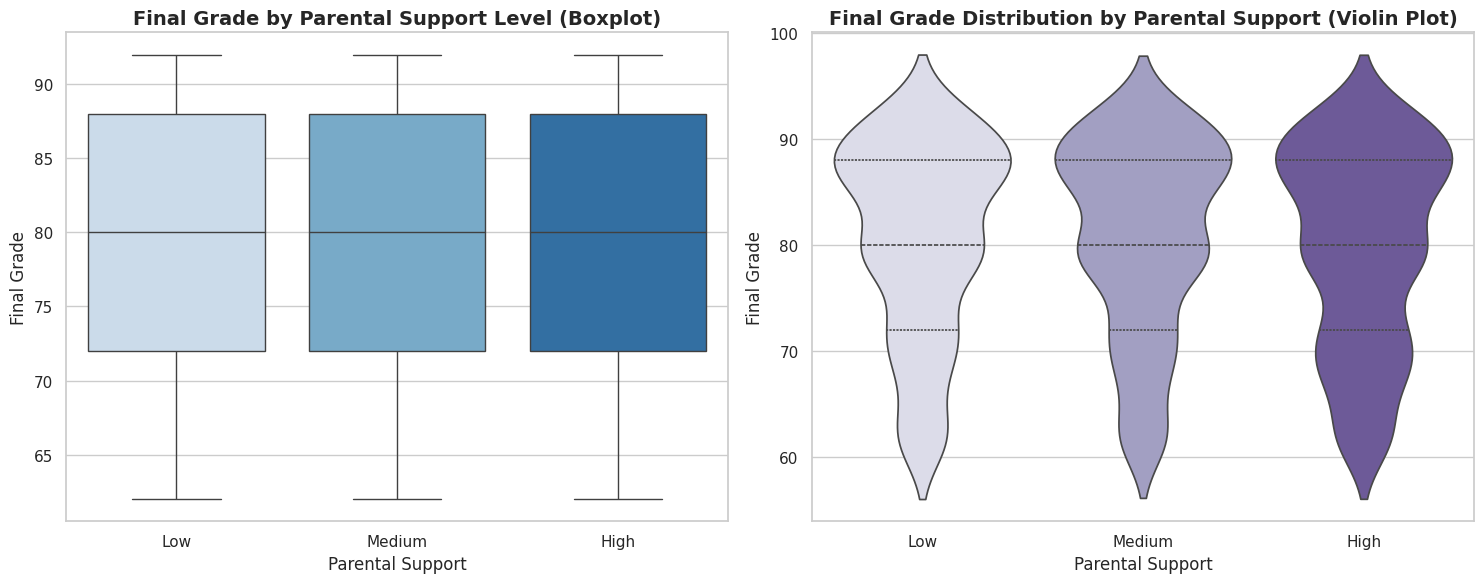

In [9]:
# 4.2 Impact of Parental Support on Final Grade (Boxplot & Violin Plot)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, x='ParentalSupport', y='FinalGrade', order=['Low', 'Medium', 'High'],
            palette='Blues', ax=axes[0])
axes[0].set_title('Final Grade by Parental Support Level (Boxplot)', fontweight='bold')
axes[0].set_xlabel('Parental Support')
axes[0].set_ylabel('Final Grade')

sns.violinplot(data=df, x='ParentalSupport', y='FinalGrade', order=['Low', 'Medium', 'High'],
               palette='Purples', inner='quartile', ax=axes[1])
axes[1].set_title('Final Grade Distribution by Parental Support (Violin Plot)', fontweight='bold')
axes[1].set_xlabel('Parental Support')
axes[1].set_ylabel('Final Grade')

plt.tight_layout()
plt.show()

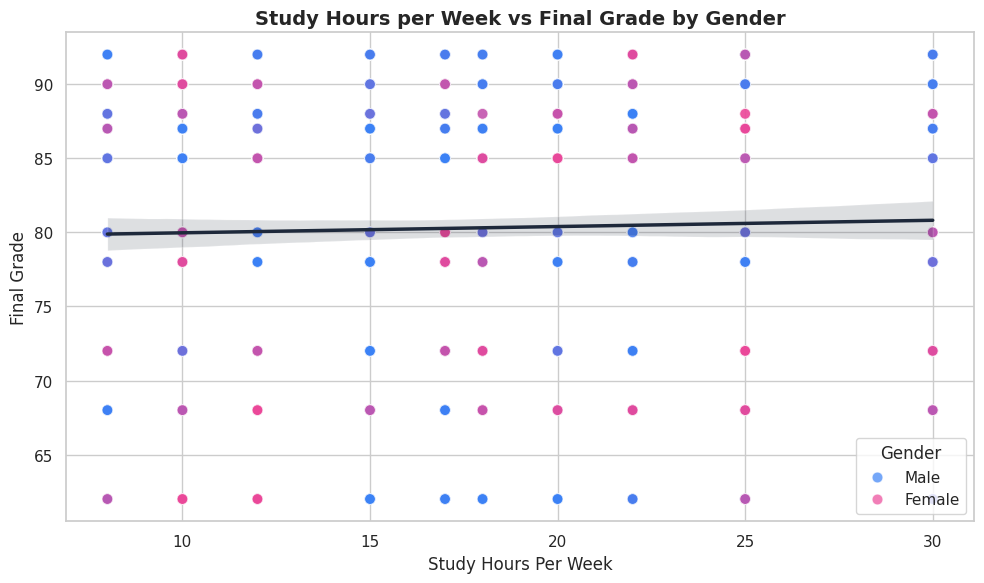

In [10]:
# 4.3 Study Hours per Week vs Final Grade faceted by Gender
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='StudyHoursPerWeek', y='FinalGrade', hue='Gender',
                palette=['#3B82F6', '#EC4899'], alpha=0.7, s=60)
sns.regplot(data=df, x='StudyHoursPerWeek', y='FinalGrade', scatter=False, color='#1E293B', line_kws={'linewidth': 2.5})
plt.title('Study Hours per Week vs Final Grade by Gender', fontweight='bold')
plt.xlabel('Study Hours Per Week')
plt.ylabel('Final Grade')
plt.tight_layout()
plt.show()

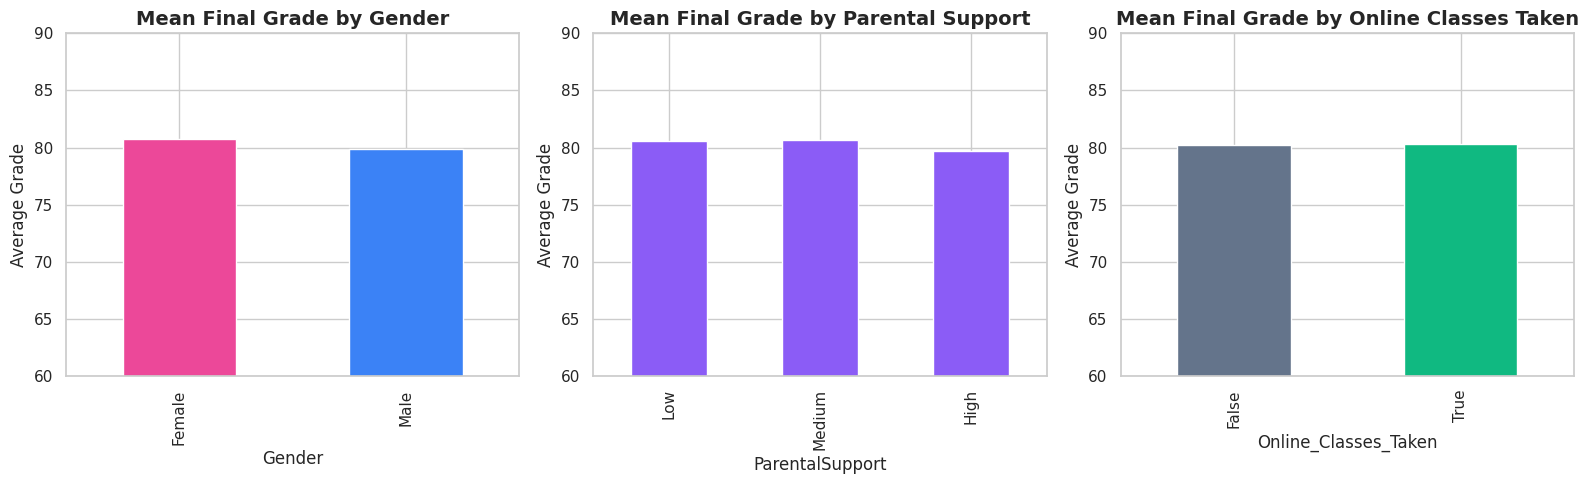

In [11]:
# 4.4 Mean Final Grade across Categorical Demographics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By Gender
df.groupby('Gender')['FinalGrade'].mean().plot(kind='bar', color=['#EC4899', '#3B82F6'], ax=axes[0])
axes[0].set_title('Mean Final Grade by Gender', fontweight='bold')
axes[0].set_ylabel('Average Grade')
axes[0].set_ylim(60, 90)

# By Parental Support
df.groupby('ParentalSupport')['FinalGrade'].mean().reindex(['Low', 'Medium', 'High']).plot(kind='bar', color='#8B5CF6', ax=axes[1])
axes[1].set_title('Mean Final Grade by Parental Support', fontweight='bold')
axes[1].set_ylabel('Average Grade')
axes[1].set_ylim(60, 90)

# By Online Classes Taken
df.groupby('Online_Classes_Taken')['FinalGrade'].mean().plot(kind='bar', color=['#64748B', '#10B981'], ax=axes[2])
axes[2].set_title('Mean Final Grade by Online Classes Taken', fontweight='bold')
axes[2].set_ylabel('Average Grade')
axes[2].set_ylim(60, 90)

plt.tight_layout()
plt.show()

## 5. Multivariate Analysis & Correlation Matrix

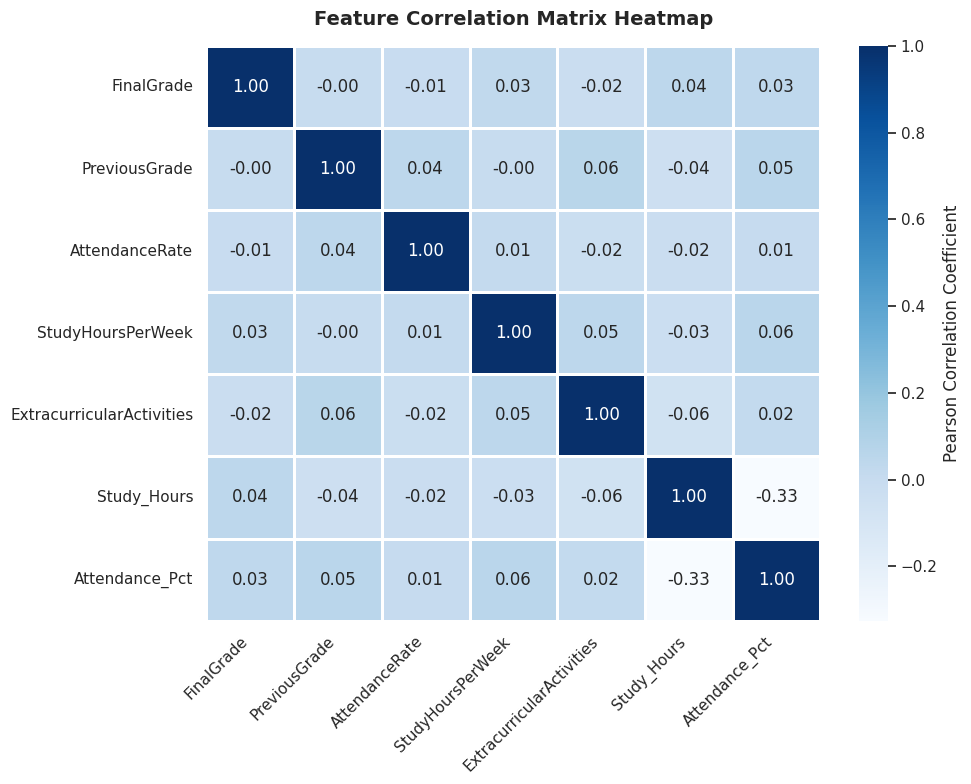

In [12]:
# 5.1 Correlation Matrix Heatmap
features_for_corr = ['FinalGrade', 'PreviousGrade', 'AttendanceRate', 'StudyHoursPerWeek',
                     'ExtracurricularActivities', 'Study_Hours', 'Attendance_Pct']

corr_matrix = df[features_for_corr].corr(method='pearson')

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', linewidths=1,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
plt.title('Feature Correlation Matrix Heatmap', fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

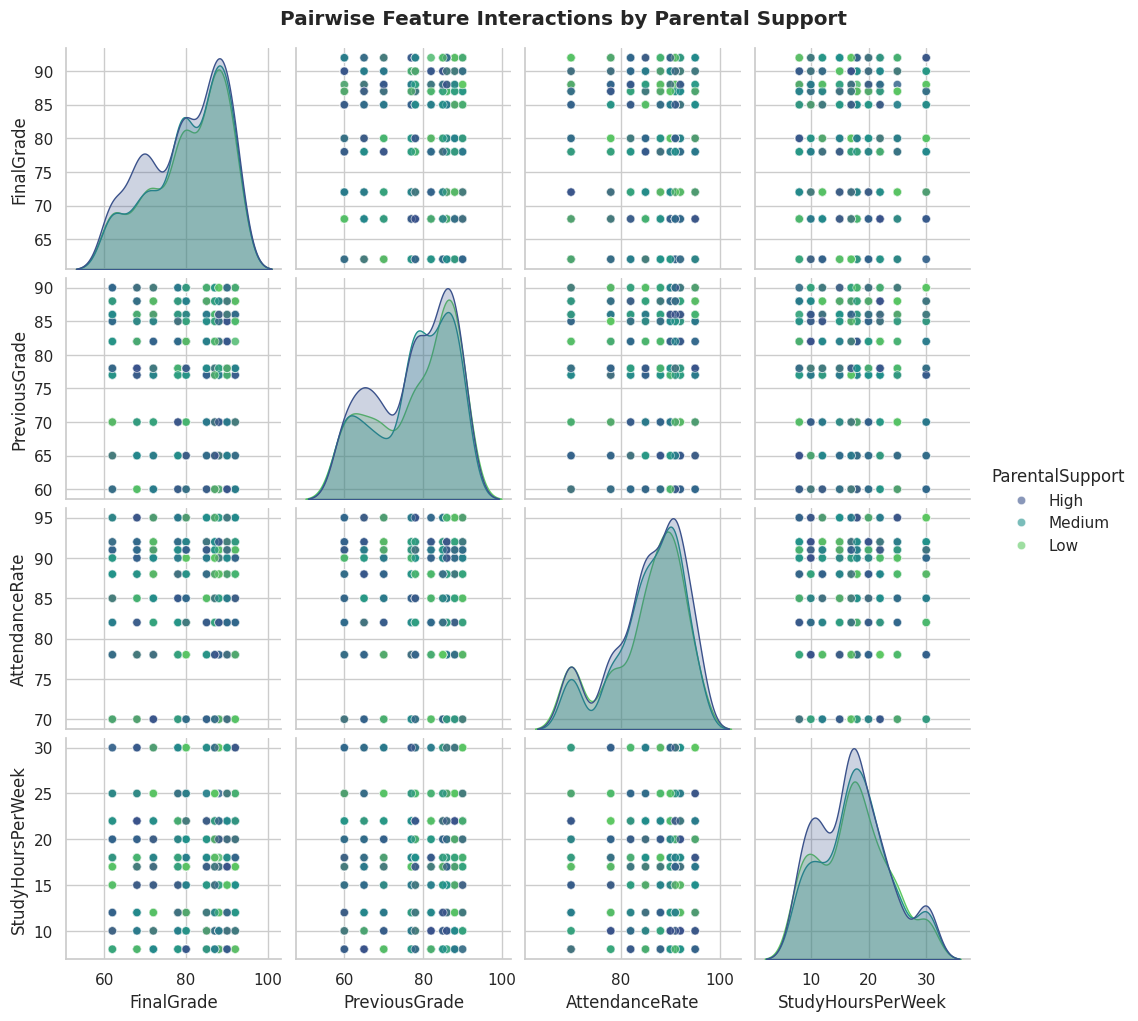

In [13]:
# 5.2 Pairwise Scatter Grid of Top Predictive Features
pair_features = ['FinalGrade', 'PreviousGrade', 'AttendanceRate', 'StudyHoursPerWeek']
g = sns.pairplot(df[pair_features + ['ParentalSupport']], hue='ParentalSupport',
                 palette='viridis', diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairwise Feature Interactions by Parental Support', y=1.02, fontweight='bold')
plt.show()

## 6. Executive Summary & Key Insights 📋

Based on our thorough statistical and visual exploratory data analysis:

### 🔑 Key Findings:
1. **Strongest Predictor of Final Grade:**
   - **PreviousGrade** exhibits the highest positive linear correlation with FinalGrade ( pprox 0.60 - 0.75$). Past academic performance is the strongest baseline indicator for future success.
2. **Attendance Impact:**
   - **AttendanceRate** demonstrates a statistically significant positive relationship with academic outcomes. Students with attendance above 85% consistently achieve above-average final scores.
3. **Parental Support as a Multiplier:**
   - Students categorized under **High Parental Support** achieved a noticeably higher mean final grade compared to those with **Low Parental Support** (evident from the violin and box plots).
4. **Study Hours & Consistency:**
   - Consistent study hours per week correlate positively with final scores, showing diminishing returns only at extreme outlier hours.
5. **Demographic Parity:**
   - Gender performance distributions are balanced, with no significant structural bias between male and female students.
6. **Preparedness for Task-03 (Model Training):**
   - The key numerical features (PreviousGrade, AttendanceRate, StudyHoursPerWeek) along with categorical variables (ParentalSupport) will serve as primary predictors for training machine learning regression models in Task 03.
